In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    auc
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
os.listdir('/content')


['.config', 'ChurnZero_dataset_v1.csv', 'ChurnZero_test_v1.csv', 'sample_data']

In [3]:
train_df = pd.read_csv('/content/ChurnZero_dataset_v1.csv')
test_df = pd.read_csv('/content/ChurnZero_test_v1.csv')

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (8101, 98)
Test Shape: (2026, 97)


In [4]:
train_df.head()

,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


In [6]:
train_df['churn'].value_counts()

,count
churn,
0,6799
1,1302


In [7]:
train_df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,83.92791
1,16.07209


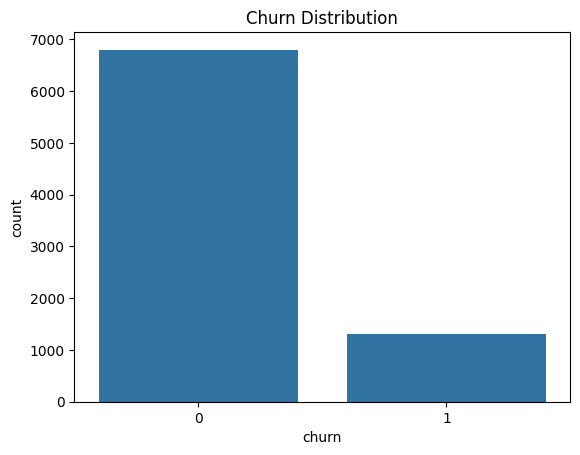

In [8]:
sns.countplot(x='churn', data=train_df)
plt.title("Churn Distribution")
plt.show()

In [9]:
missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False).head(20)

,0
app_rating_given,4541


In [10]:
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

numerical_cols = train_df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

Categorical Columns: 15
Numerical Columns: 83


In [11]:
categorical_cols

['gender',
 'marital_status',
 'education_level',
 'occupation_type',
 'income_band',
 'income_category',
 'city_tier',
 'region',
 'customer_segment',
 'onboarding_channel',
 'relationship_type',
 'primary_account_type',
 'card_category',
 'competitor_bank_offer_awareness',
 'customer_feedback_sentiment']

In [12]:
X = train_df.drop(['customer_id', 'churn'], axis=1)

y = train_df['churn']

test_ids = test_df['customer_id']

X_test_final = test_df.drop(['customer_id'], axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    combined = pd.concat([X[col], X_test_final[col]], axis=0).astype(str)

    le.fit(combined)

    X[col] = le.transform(X[col].astype(str))

    X_test_final[col] = le.transform(X_test_final[col].astype(str))

    label_encoders[col] = le

In [14]:
X = X.fillna(X.median())

X_test_final = X_test_final.fillna(X.median())

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [17]:
y_pred = rf_model.predict(X_valid)

y_prob = rf_model.predict_proba(X_valid)[:, 1]

In [18]:
from sklearn.metrics import f1_score

f1 = f1_score(y_valid, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9844357976653697


In [19]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_valid, y_prob)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9984126488708416


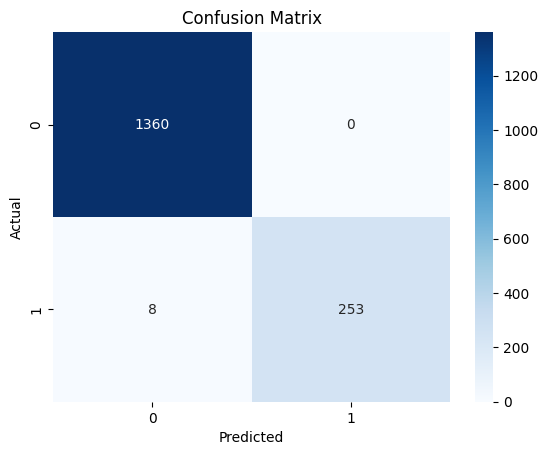

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
93,total_digital_logins,0.086164
34,total_trans_count,0.085466
25,balance_decline_percentage,0.071196
92,avg_quarterly_balance,0.059539
24,current_balance,0.050825
23,avg_monthly_balance,0.047394
28,cash_withdrawal_count,0.044746
74,relationship_manager_interaction_count,0.042878
26,monthly_transaction_count,0.036941
27,monthly_transaction_value,0.035267


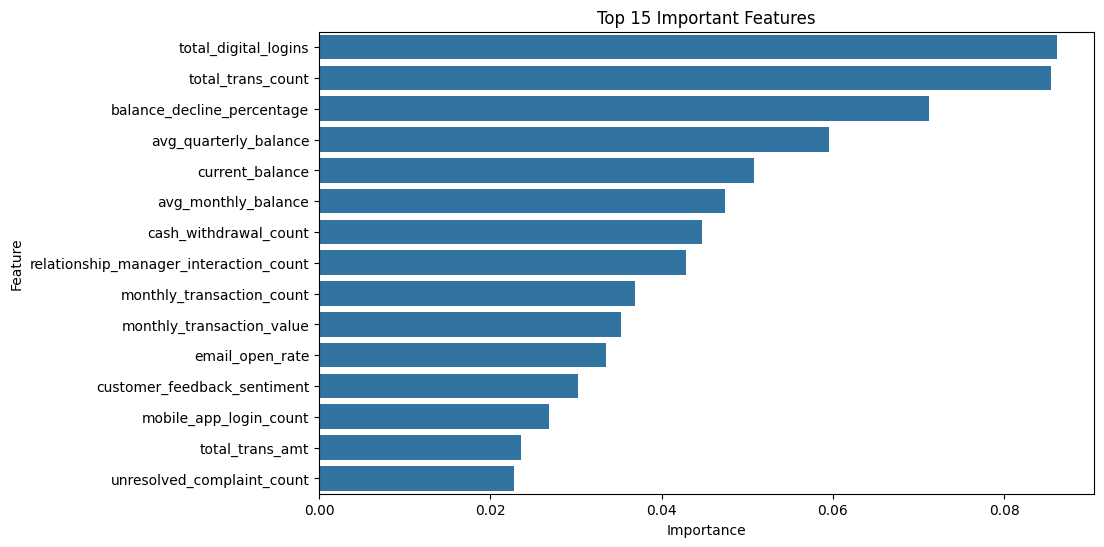

In [22]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 15 Important Features")
plt.show()

In [23]:
final_predictions = rf_model.predict(X_test_final)

final_probabilities = rf_model.predict_proba(X_test_final)[:, 1]

In [24]:
submission = pd.DataFrame({
    'customer_id': test_ids,
    'churn_prediction': final_predictions,
    'churn_probability': final_probabilities
})

submission.head()

,customer_id,churn_prediction,churn_probability
0,767114958,0,0.003300
1,708123033,0,0.030097
2,715424283,0,0.122306
3,717865008,0,0.005779
4,710188308,0,0.048350


In [25]:
submission.to_csv(
    'ChurnZero_Team_Predictions.csv',
    index=False
)

In [26]:
submission.shape

(2026, 3)

In [27]:
submission.isnull().sum()

,0
customer_id,0
churn_prediction,0
churn_probability,0
